# Baseline MLP Classifier for EEG Image Classification

**Task:** Classify which of 20 object categories a subject was viewing from EEG signals (122 channels × 500ms).

**Model:** Simple fully-connected network (flatten → FC layers → 20 logits).

**Expected accuracy:** ~8-12% (chance = 5%).

In [1]:
import os, pickle, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: Tesla V100-SXM2-32GB


## 1. Data Loading

In [2]:
PROJECT_DIR = '/jet/home/sharmar/eeg-project'
ARTIFACTS    = os.path.join(PROJECT_DIR, 'artifacts')

# Load CSV splits
train_df = pd.read_csv(os.path.join(ARTIFACTS, 'train.csv'))
val_df   = pd.read_csv(os.path.join(ARTIFACTS, 'val.csv'))
test_df  = pd.read_csv(os.path.join(ARTIFACTS, 'test.csv'))

# Load normalization stats, label mappings, bad channels
with open(os.path.join(ARTIFACTS, 'norm_stats.pkl'), 'rb') as f:
    norm_data = pickle.load(f)
with open(os.path.join(ARTIFACTS, 'label_mappings.pkl'), 'rb') as f:
    mappings = pickle.load(f)
with open(os.path.join(ARTIFACTS, 'bad_channels.pkl'), 'rb') as f:
    bad_channels = pickle.load(f)

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")
print(f"Categories: {list(mappings['cat_to_idx'].keys())}")
print(f"Subjects: {list(mappings['sub_to_idx'].keys())}")
print(f"Bad channels: {bad_channels}")

Train: 15600, Val: 5200, Test: 5200
Categories: ['aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus', 'car', 'cat', 'chair', 'cow', 'diningtable', 'dog', 'flower', 'horse', 'motorbike', 'person', 'sheep', 'sofa', 'train', 'tvmonitor']
Subjects: ['sub-02', 'sub-03', 'sub-05', 'sub-09', 'sub-14', 'sub-15', 'sub-17', 'sub-19', 'sub-20', 'sub-23', 'sub-24', 'sub-28', 'sub-29']
Bad channels: {'sub-19': [53, 88], 'sub-29': [82], 'sub-03': []}


## 2. EEGDataset & Collate Function (from data pipeline)

In [3]:
class EEGDataset(Dataset):
    """Loads EEG trials on-the-fly with per-file caching.

    Data on disk: (100, 500, 122) = (trials, timepoints, channels)
    Output:       (122, 500)      = (channels, timepoints)

    Returns:
        eeg_tensor  : (122, 500) float32
        label       : int  (category index)
        subject_id  : int  (subject index)
        metadata    : dict (includes caption for CLIP models)
    """

    def __init__(self, df, normalize='subject_channel', norm_stats=None,
                 clip_threshold=800.0, max_cache=50, bad_channels=None):
        self.df = df.reset_index(drop=True)
        self.normalize = normalize
        self.norm_stats = norm_stats
        self.clip_threshold = clip_threshold
        self.max_cache = max_cache
        self.bad_channels = bad_channels or {}
        self._cache = {}
        self._cache_order = []

        self.subjects = sorted(df['subject'].unique())
        self.sub_to_idx = {s: i for i, s in enumerate(self.subjects)}

    def _load_npy(self, path):
        if path not in self._cache:
            if self.max_cache and len(self._cache) >= self.max_cache:
                oldest = self._cache_order.pop(0)
                del self._cache[oldest]
            self._cache[path] = np.load(path)
            self._cache_order.append(path)
        return self._cache[path]

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        eeg_all = self._load_npy(row['npy_path'])
        eeg = eeg_all[row['trial_idx']].astype(np.float32)  # (500, 122)

        # Transpose: (500, 122) -> (122, 500) = (channels, timepoints)
        eeg = eeg.T  # (122, 500)

        # Clip extreme amplitudes
        if self.clip_threshold is not None:
            eeg = np.clip(eeg, -self.clip_threshold, self.clip_threshold)

        # Normalize
        if self.normalize == 'subject_channel' and self.norm_stats is not None:
            sub = row['subject']
            mu  = self.norm_stats[sub]['mean'][:, None]   # (122, 1)
            std = self.norm_stats[sub]['std'][:, None]    # (122, 1)
            eeg = (eeg - mu) / std
        elif self.normalize == 'per_trial':
            mu, sigma = eeg.mean(), eeg.std() + 1e-8
            eeg = (eeg - mu) / sigma
        elif self.normalize == 'per_channel':
            mu    = eeg.mean(axis=1, keepdims=True)
            sigma = eeg.std(axis=1, keepdims=True) + 1e-8
            eeg = (eeg - mu) / sigma

        # Zero out bad channels
        sub = row['subject']
        if sub in self.bad_channels and len(self.bad_channels[sub]) > 0:
            eeg[self.bad_channels[sub], :] = 0.0

        eeg_tensor = torch.from_numpy(eeg)  # (122, 500)
        label      = int(row['label'])
        subject_id = self.sub_to_idx[row['subject']]

        metadata = dict(
            subject    = row['subject'],
            session    = row['session'],
            run        = row['run'],
            trial_idx  = row['trial_idx'],
            category   = row['category'],
            image_name = row['image_name'],
            caption    = row.get('caption', ''),
        )
        return eeg_tensor, label, subject_id, metadata


def eeg_collate_fn(batch):
    """Stack tensors, collate metadata into dict-of-lists."""
    eegs, labels, sub_ids, metas = zip(*batch)
    return (
        torch.stack(eegs),                              # (B, 122, 500)
        torch.tensor(labels, dtype=torch.long),         # (B,)
        torch.tensor(sub_ids, dtype=torch.long),        # (B,)
        {k: [m[k] for m in metas] for k in metas[0]},  # dict of lists
    )

In [4]:
# Create datasets and dataloaders
BATCH_SIZE = 64

train_ds = EEGDataset(train_df, normalize='subject_channel',
                      norm_stats=norm_data['per_subject'],
                      clip_threshold=norm_data['clip_threshold'],
                      bad_channels=bad_channels)
val_ds   = EEGDataset(val_df, normalize='subject_channel',
                      norm_stats=norm_data['per_subject'],
                      clip_threshold=norm_data['clip_threshold'],
                      bad_channels=bad_channels)
test_ds  = EEGDataset(test_df, normalize='subject_channel',
                      norm_stats=norm_data['per_subject'],
                      clip_threshold=norm_data['clip_threshold'],
                      bad_channels=bad_channels)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          collate_fn=eeg_collate_fn, num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                          collate_fn=eeg_collate_fn, num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                          collate_fn=eeg_collate_fn, num_workers=4, pin_memory=True)

# Sanity check
eeg_batch, labels, sub_ids, meta = next(iter(train_loader))
print(f"EEG batch shape: {eeg_batch.shape}")    # (64, 122, 500)
print(f"Labels shape: {labels.shape}")           # (64,)
print(f"Subject IDs shape: {sub_ids.shape}")     # (64,)
print(f"Label range: {labels.min().item()} - {labels.max().item()}")

EEG batch shape: torch.Size([64, 122, 500])
Labels shape: torch.Size([64])
Subject IDs shape: torch.Size([64])
Label range: 0 - 19


## 3. Baseline MLP Model

In [5]:
class BaselineMLP(nn.Module):
    """Simple fully-connected baseline for EEG classification.

    Input: (B, 122, 500) -> flatten -> 61,000
    Hidden: 61000 -> 1024 -> 512 -> 256 -> 20
    """

    def __init__(self, input_dim=122*500, num_classes=20,
                 hidden_dims=(1024, 512, 256), dropout=0.5):
        super().__init__()
        layers = []
        prev_dim = input_dim
        for h_dim in hidden_dims:
            layers.extend([
                nn.Linear(prev_dim, h_dim),
                nn.BatchNorm1d(h_dim),
                nn.ReLU(),
                nn.Dropout(dropout),
            ])
            prev_dim = h_dim
        layers.append(nn.Linear(prev_dim, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        # x: (B, 122, 500)
        x = x.view(x.size(0), -1)  # (B, 61000)
        return self.net(x)          # (B, 20) — raw logits


model = BaselineMLP().to(device)
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(model)

Total parameters: 63,129,876
Trainable parameters: 63,129,876
BaselineMLP(
  (net): Sequential(
    (0): Linear(in_features=61000, out_features=1024, bias=True)
    (1): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=1024, out_features=512, bias=True)
    (5): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.5, inplace=False)
    (8): Linear(in_features=512, out_features=256, bias=True)
    (9): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.5, inplace=False)
    (12): Linear(in_features=256, out_features=20, bias=True)
  )
)


## 4. Training Loop

In [6]:
# Hyperparameters
NUM_EPOCHS = 50
LR = 1e-3
WEIGHT_DECAY = 1e-4
PATIENCE = 7  # early stopping patience

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3, verbose=True
)

CHECKPOINT_PATH = os.path.join(PROJECT_DIR, 'checkpoints')
os.makedirs(CHECKPOINT_PATH, exist_ok=True)

/ocean/projects/cis250019p/mzhang23/TA/envs/IDLS26/lib/python3.11/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [7]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for eeg, labels, sub_ids, meta in loader:
        eeg, labels = eeg.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(eeg)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * eeg.size(0)
        correct += (logits.argmax(1) == labels).sum().item()
        total += eeg.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels, all_subs = [], [], []
    for eeg, labels, sub_ids, meta in loader:
        eeg, labels = eeg.to(device), labels.to(device)
        logits = model(eeg)
        loss = criterion(logits, labels)

        total_loss += loss.item() * eeg.size(0)
        preds = logits.argmax(1)
        correct += (preds == labels).sum().item()
        total += eeg.size(0)

        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())
        all_subs.extend(meta['subject'])

    all_preds = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)
    return total_loss / total, correct / total, all_preds, all_labels, all_subs

In [8]:
# Training loop with early stopping
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_loss = float('inf')
patience_counter = 0

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()

    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, _, _, _ = evaluate(model, val_loader, criterion, device)

    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    elapsed = time.time() - t0
    print(f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
          f"Train Loss: {train_loss:.4f}  Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}  Acc: {val_acc:.4f} | "
          f"LR: {optimizer.param_groups[0]['lr']:.2e} | {elapsed:.1f}s")

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': val_loss,
            'val_acc': val_acc,
        }, os.path.join(CHECKPOINT_PATH, 'baseline_mlp_best.pt'))
        print(f"  -> Saved best model (val_loss={val_loss:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"Early stopping at epoch {epoch} (no improvement for {PATIENCE} epochs)")
            break

print(f"\nBest val loss: {best_val_loss:.4f}")

Epoch 01/50 | Train Loss: 3.0686  Acc: 0.0551 | Val Loss: 3.0798  Acc: 0.0562 | LR: 1.00e-03 | 33.5s
  -> Saved best model (val_loss=3.0798)
Epoch 02/50 | Train Loss: 3.0133  Acc: 0.0635 | Val Loss: 3.0019  Acc: 0.0644 | LR: 1.00e-03 | 26.1s
  -> Saved best model (val_loss=3.0019)
Epoch 03/50 | Train Loss: 2.9829  Acc: 0.0704 | Val Loss: 3.0011  Acc: 0.0700 | LR: 1.00e-03 | 25.5s
  -> Saved best model (val_loss=3.0011)
Epoch 04/50 | Train Loss: 2.9648  Acc: 0.0779 | Val Loss: 2.9975  Acc: 0.0710 | LR: 1.00e-03 | 25.1s
  -> Saved best model (val_loss=2.9975)
Epoch 05/50 | Train Loss: 2.9519  Acc: 0.0852 | Val Loss: 3.0147  Acc: 0.0783 | LR: 1.00e-03 | 26.8s
Epoch 06/50 | Train Loss: 2.9383  Acc: 0.0865 | Val Loss: 2.9815  Acc: 0.0737 | LR: 1.00e-03 | 25.0s
  -> Saved best model (val_loss=2.9815)
Epoch 07/50 | Train Loss: 2.9296  Acc: 0.0883 | Val Loss: 2.9910  Acc: 0.0806 | LR: 1.00e-03 | 24.9s
Epoch 08/50 | Train Loss: 2.9243  Acc: 0.0944 | Val Loss: 2.9913  Acc: 0.0769 | LR: 1.00e-03 

## 5. Training Curves

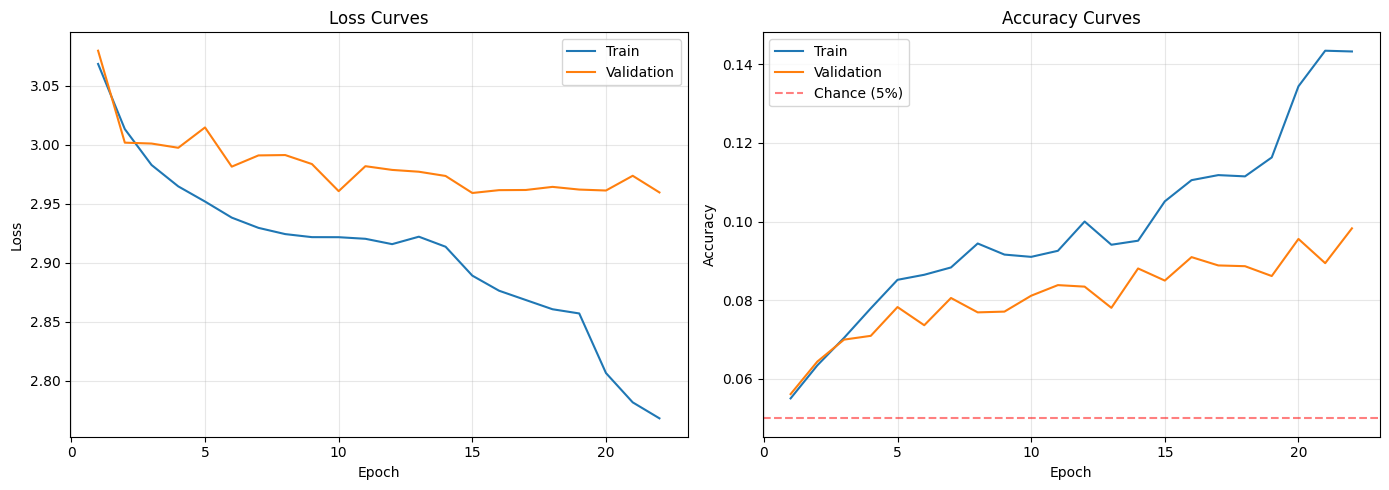

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, len(history['train_loss']) + 1)

ax1.plot(epochs_range, history['train_loss'], label='Train')
ax1.plot(epochs_range, history['val_loss'], label='Validation')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Loss Curves')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range, history['train_acc'], label='Train')
ax2.plot(epochs_range, history['val_acc'], label='Validation')
ax2.axhline(y=0.05, color='r', linestyle='--', alpha=0.5, label='Chance (5%)')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy Curves')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(ARTIFACTS, 'baseline_mlp_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

## 6. Test Set Evaluation

In [10]:
# Load best model
ckpt = torch.load(os.path.join(CHECKPOINT_PATH, 'baseline_mlp_best.pt'), map_location=device)
model.load_state_dict(ckpt['model_state_dict'])
print(f"Loaded best model from epoch {ckpt['epoch']} (val_loss={ckpt['val_loss']:.4f}, val_acc={ckpt['val_acc']:.4f})")

# Evaluate on test set
test_loss, test_acc, test_preds, test_labels, test_subs = evaluate(
    model, test_loader, criterion, device
)
print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"Chance level: 5.00%")

/var/tmp/ipykernel_34826/3916727809.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(os.path.join(CHECKPOINT_PATH, 'baseline_mlp_best.pt'), map_location

Loaded best model from epoch 15 (val_loss=2.9592, val_acc=0.0850)

Test Loss: 2.9407
Test Accuracy: 0.0873 (8.73%)
Chance level: 5.00%


### Per-Subject Accuracy

In [11]:
# Per-subject accuracy
subject_correct = {}
subject_total = {}
for pred, label, sub in zip(test_preds, test_labels, test_subs):
    sub = str(sub)
    if sub not in subject_correct:
        subject_correct[sub] = 0
        subject_total[sub] = 0
    subject_total[sub] += 1
    if pred.item() == label.item():
        subject_correct[sub] += 1

print(f"{'Subject':<10} {'Accuracy':>10} {'Correct':>10} {'Total':>8}")
print("-" * 40)
for sub in sorted(subject_correct.keys()):
    acc = subject_correct[sub] / subject_total[sub]
    print(f"{sub:<10} {acc:>10.4f} {subject_correct[sub]:>10} {subject_total[sub]:>8}")

# Highlight noisy subjects
print("\nNote: sub-03, sub-19, sub-20 are known to be noisier.")

Subject      Accuracy    Correct    Total
----------------------------------------
sub-02         0.0850         34      400
sub-03         0.0550         22      400
sub-05         0.0825         33      400
sub-09         0.0975         39      400
sub-14         0.0925         37      400
sub-15         0.0725         29      400
sub-17         0.1075         43      400
sub-19         0.1025         41      400
sub-20         0.0675         27      400
sub-23         0.1100         44      400
sub-24         0.0875         35      400
sub-28         0.1000         40      400
sub-29         0.0750         30      400

Note: sub-03, sub-19, sub-20 are known to be noisier.


### Confusion Matrix

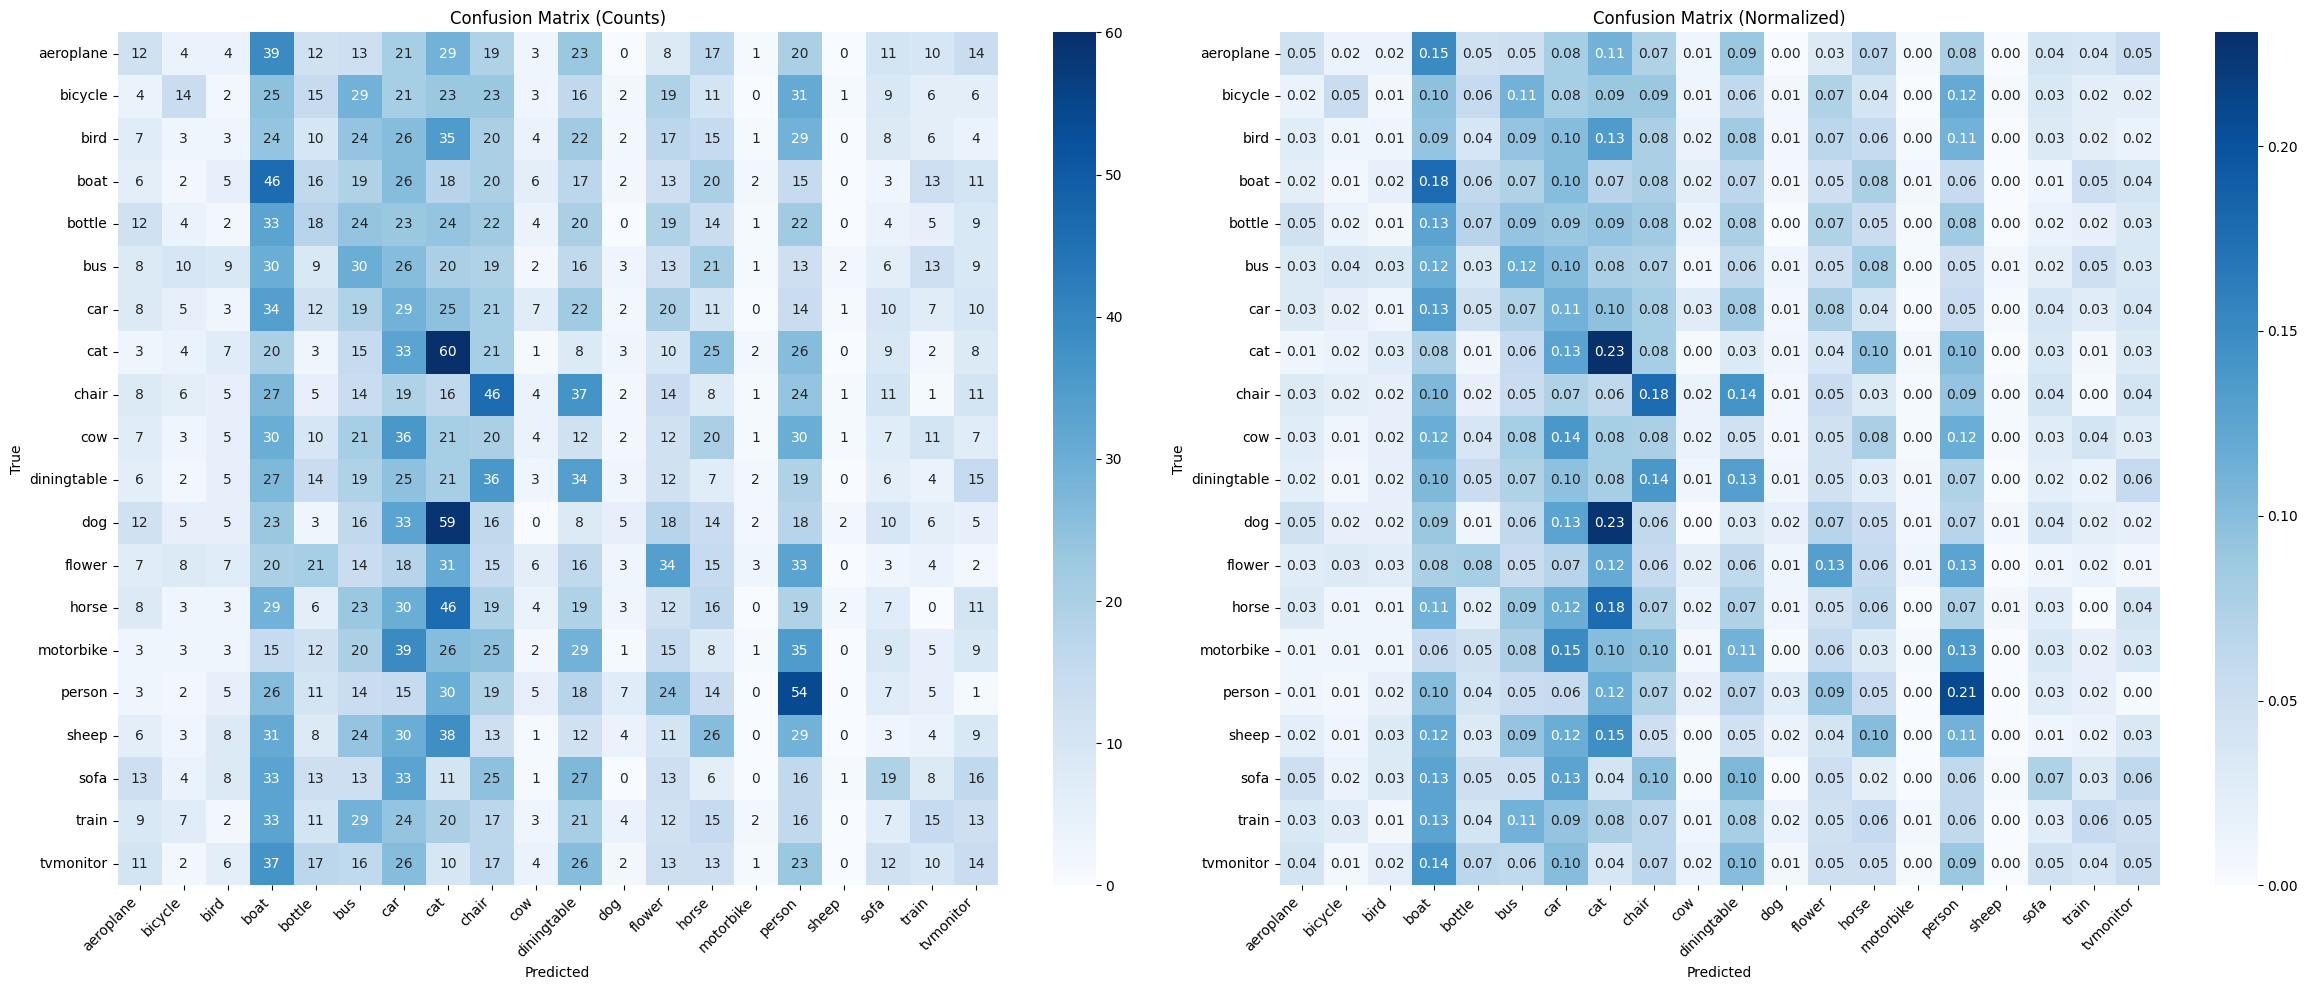

In [12]:
from sklearn.metrics import confusion_matrix

idx_to_cat = mappings['idx_to_cat']
category_names = [idx_to_cat[i] for i in range(20)]

cm = confusion_matrix(test_labels.numpy(), test_preds.numpy(), labels=range(20))

# Normalize by row (true label) for better visualization
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 10))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=category_names, yticklabels=category_names)
ax1.set_xlabel('Predicted')
ax1.set_ylabel('True')
ax1.set_title('Confusion Matrix (Counts)')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

# Normalized
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', ax=ax2,
            xticklabels=category_names, yticklabels=category_names)
ax2.set_xlabel('Predicted')
ax2.set_ylabel('True')
ax2.set_title('Confusion Matrix (Normalized)')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig(os.path.join(ARTIFACTS, 'baseline_mlp_confusion.png'), dpi=150, bbox_inches='tight')
plt.show()

### Most Confused Category Pairs

In [13]:
# Find most confused pairs (off-diagonal entries in confusion matrix)
confused_pairs = []
for i in range(20):
    for j in range(20):
        if i != j:
            confused_pairs.append((category_names[i], category_names[j], cm[i, j]))

confused_pairs.sort(key=lambda x: x[2], reverse=True)

print("Top 15 Most Confused Pairs (True -> Predicted : Count)")
print("-" * 55)
for true_cat, pred_cat, count in confused_pairs[:15]:
    print(f"  {true_cat:<15} -> {pred_cat:<15} : {count}")

Top 15 Most Confused Pairs (True -> Predicted : Count)
-------------------------------------------------------
  dog             -> cat             : 59
  horse           -> cat             : 46
  aeroplane       -> boat            : 39
  motorbike       -> car             : 39
  sheep           -> cat             : 38
  chair           -> diningtable     : 37
  tvmonitor       -> boat            : 37
  cow             -> car             : 36
  diningtable     -> chair           : 36
  bird            -> cat             : 35
  motorbike       -> person          : 35
  car             -> boat            : 34
  bottle          -> boat            : 33
  cat             -> car             : 33
  dog             -> car             : 33


## 7. Kaggle Submission CSV

In [14]:
# Generate Kaggle submission CSV
# Format: Id, Category (predicted label index or category name)
submission = pd.DataFrame({
    'Id': range(len(test_preds)),
    'Category': test_preds.numpy(),
})
submission_path = os.path.join(PROJECT_DIR, 'submission_baseline_mlp.csv')
submission.to_csv(submission_path, index=False)
print(f"Submission saved to {submission_path}")
print(f"Shape: {submission.shape}")
print(submission.head(10))

Submission saved to /jet/home/sharmar/eeg-project/submission_baseline_mlp.csv
Shape: (5200, 2)
   Id  Category
0   0         5
1   1         9
2   2        13
3   3         5
4   4        15
5   5        13
6   6        18
7   7        18
8   8         0
9   9         7


## 8. Summary

In [15]:
print("=" * 60)
print("BASELINE MLP SUMMARY")
print("=" * 60)
print(f"Architecture: Flatten(122x500) -> 1024 -> 512 -> 256 -> 20")
print(f"Parameters: {total_params:,}")
print(f"Best epoch: {ckpt['epoch']}")
print(f"Best val loss: {ckpt['val_loss']:.4f}")
print(f"Best val acc: {ckpt['val_acc']:.4f} ({ckpt['val_acc']*100:.2f}%)")
print(f"Test acc: {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"Chance level: 5.00%")
print(f"Checkpoint: {os.path.join(CHECKPOINT_PATH, 'baseline_mlp_best.pt')}")
print(f"Submission: {submission_path}")
print("=" * 60)

BASELINE MLP SUMMARY
Architecture: Flatten(122x500) -> 1024 -> 512 -> 256 -> 20
Parameters: 63,129,876
Best epoch: 15
Best val loss: 2.9592
Best val acc: 0.0850 (8.50%)
Test acc: 0.0873 (8.73%)
Chance level: 5.00%
Checkpoint: /jet/home/sharmar/eeg-project/checkpoints/baseline_mlp_best.pt
Submission: /jet/home/sharmar/eeg-project/submission_baseline_mlp.csv
